In [114]:
### LOAD LIBRARIES ###

import pandas as pd
import numpy as np
import tensorflow 
from tensorflow import keras
from keras import layers
import os

In [115]:
### IMPORT DATA ###

wd = os.getcwd()

train = pd.read_csv(f"{wd}/airbnb/airbnb_train.csv")
X_train = train.drop("price", axis=1)
y_train = train["price"]

valid = pd.read_csv(f"{wd}/airbnb/airbnb_valid.csv")
X_valid = valid.drop("price", axis=1)
y_valid = valid["price"]

X_test = pd.read_csv(f"{wd}/airbnb/airbnb_test.csv")

# We dropped irrelevant variables based on the assumption that they would not be helpful for price prediction.
# ...

vars_to_drop = ['name', 'host_name', 'last_review', 'neighbourhood_group']

X_train = X_train.drop(vars_to_drop, axis=1)
X_valid = X_valid.drop(vars_to_drop, axis=1)
X_test = X_test.drop(vars_to_drop, axis=1)

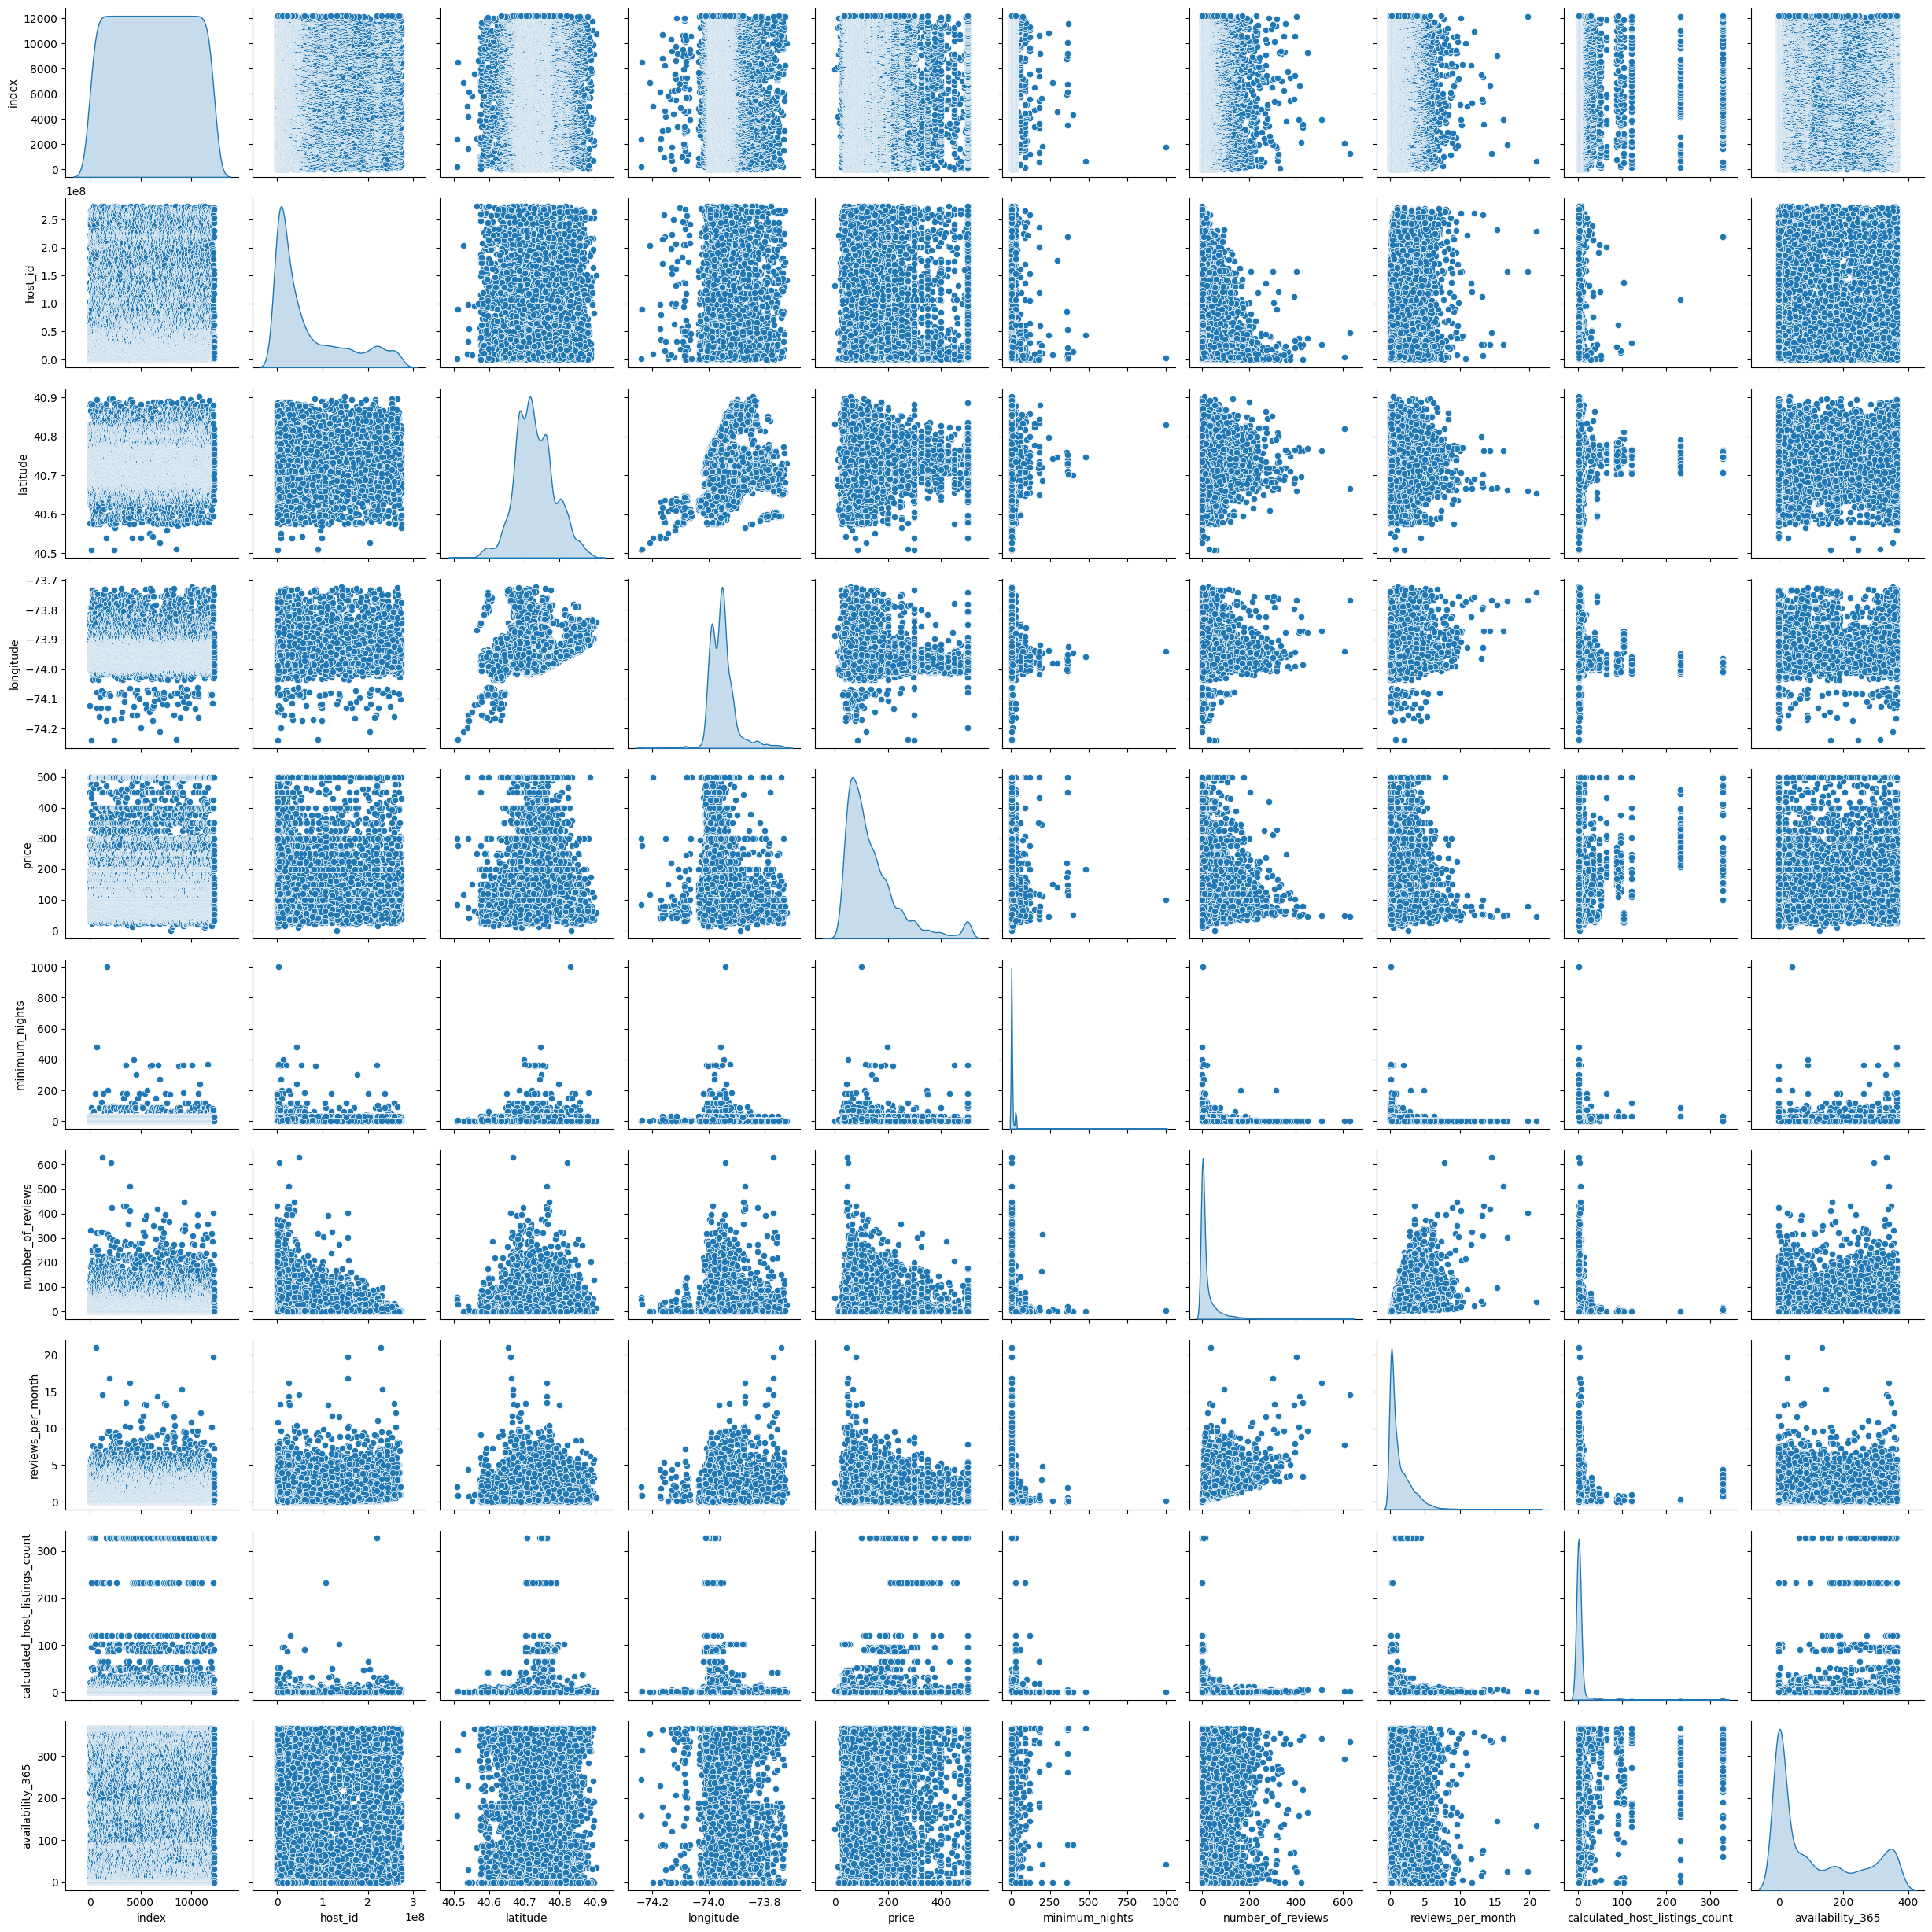

In [116]:
import seaborn as sns

sns.pairplot(train, diag_kind='kde')

# GABI: I think latitude and longitude could be merged, as well as the number of reviews with reviews per month.

In [ ]:
### COMPUTE NEW VARIABLES ###

# ...

In [117]:
### PREPROCESS DATA ###

vars_to_cat = ['host_id', 'neighbourhood', 'room_type']  # List of categorical variables to hot encode
vars_to_norm = [i for i in X_train.columns if i not in vars_to_cat]             # List of numerical variables to normalize

# Standardize numerical variables

X_train_mean = np.mean(X_train[vars_to_norm])
X_train_std = np.std(X_train[vars_to_norm])

X_train[vars_to_norm] = (X_train[vars_to_norm] - X_train_mean) / X_train_std
X_valid[vars_to_norm] = (X_valid[vars_to_norm] - X_train_mean) / X_train_std
X_test[vars_to_norm] = (X_test[vars_to_norm] - X_train_mean) / X_train_std

# Hot encode categorical variables

for var in vars_to_cat:
    cats = X_train[var].astype("category").cat.categories
    X_train[var] = pd.Categorical(X_train[var], categories=cats).codes
    X_valid[var] = pd.Categorical(X_valid[var], categories=cats).codes
    X_test[var]  = pd.Categorical(X_test[var],  categories=cats).codes

# The variable review_per_month is the only one with missing values.
# Missing values of review_per_month are tackled by substituting them with the variable mean in order to keep the row count.
rpm_mean = X_train['reviews_per_month'].mean()
X_train['reviews_per_month'] = X_train['reviews_per_month'].fillna(rpm_mean)
X_valid['reviews_per_month'] = X_valid['reviews_per_month'].fillna(rpm_mean)
X_test['reviews_per_month']  = X_test['reviews_per_month'].fillna(rpm_mean)

/var/folders/z3/0m_2wxcd31v5r24skvf_08000000gn/T/ipykernel_49826/1737693450.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_valid[var] = pd.Categorical(X_valid[var], categories=cats).codes
/var/folders/z3/0m_2wxcd31v5r24skvf_08000000gn/T/ipykernel_49826/1737693450.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[var]  = pd.Categorical(X_test[var],  categories=cats).codes
/var/folders/z3/0m_2wxcd31v5r24skvf_08000000gn/T/ipykernel_49826/1737693450.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_valid[var] = pd.Categorical(X_valid[var], categories=cats).codes
/var/folders/z3/

In [ ]:
# Run basic model

vars = len(X_train.columns)

model = keras.Sequential(
    [
        layers.Dense(vars, activation="linear"),
        layers.Dense(1, activation="linear")
    ]
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["root_mean_squared_error"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=128
)

results = model.evaluate(X_valid, y_valid)
print(f"RMSE: {results[1]:.4f}")

# RMSE: 88.4

Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 20019.9238 - root_mean_squared_error: 141.4918  
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 14044.3506 - root_mean_squared_error: 118.5089
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 12996.6094 - root_mean_squared_error: 114.0027
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - loss: 12485.5381 - root_mean_squared_error: 111.7387
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - loss: 12337.9414 - root_mean_squared_error: 111.0763
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - loss: 12296.4717 - root_mean_squared_error: 110.8895
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 12231.0488 - root_mean_squared_error: 110.5941
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 12130.9570 - root_mean_squared_error: 110.1406
Epoch 9/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - loss: 12061.4922 - root_mean_squared_error: 109.8248
Epoch 10/200
96/96 ━━━━━━━